# 1.准备工作

In [1]:
# Import
import os
import cv2
import shutil
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
RANDOM_STATE = 10086

In [2]:
# Verify GPU availability (should be A100 on Colab)
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


CUDA Available: True
GPU Device: NVIDIA GeForce RTX 3070 Ti Laptop GPU
GPU Memory: 8.59 GB


# 读取数据

In [3]:
import kagglehub
from pathlib import Path
import yaml

data_path = kagglehub.dataset_download("rupankarmajumdar/crop-pests-dataset")
print(f"Data downloaded to: {data_path}")
data_path = Path(data_path)

yaml_path = data_path / 'data.yaml'
with open(yaml_path, 'r') as file:
    yaml_config = yaml.safe_load(file)

class_names = yaml_config['names']

print("\nClass Names:")
for i, class_name in enumerate(class_names, 1):
    print(f"    {i}. {class_name}")

train_img_path = data_path / 'train' / 'images'
train_lab_path = data_path / 'train' / 'labels'

test_img_path = data_path / 'test' / 'images'
test_lab_path = data_path / 'test' / 'labels'

valid_img_path = data_path / 'valid' / 'images'
valid_lab_path = data_path / 'valid' / 'labels'

print(f"\nTrain image number: {len(list(train_img_path.glob('*.jpg')))}")
print(f"Test image number: {len(list(test_img_path.glob('*.jpg')))}")
print(f"Valid image number: {len(list(valid_img_path.glob('*.jpg')))}")

Data downloaded to: C:\Users\12235\.cache\kagglehub\datasets\rupankarmajumdar\crop-pests-dataset\versions\2

Class Names:
    1. Ants
    2. Bees
    3. Beetles
    4. Caterpillars
    5. Earthworms
    6. Earwigs
    7. Grasshoppers
    8. Moths
    9. Slugs
    10. Snails
    11. Wasps
    12. Weevils

Train image number: 11502
Test image number: 546
Valid image number: 1095


# 分析数据分布

========= Training Set Distribution =========


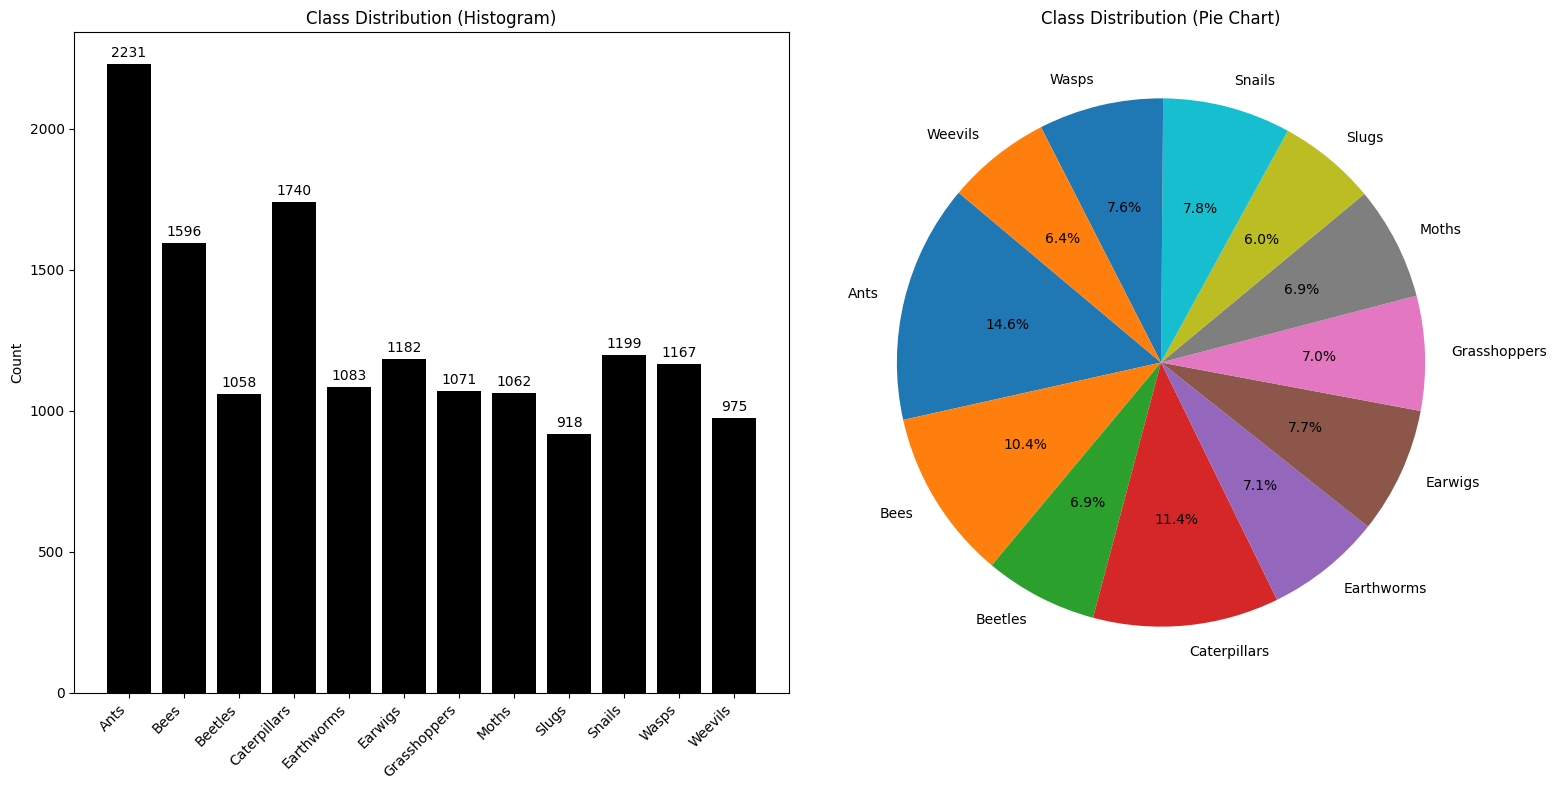

========= Test Set Distribution =========


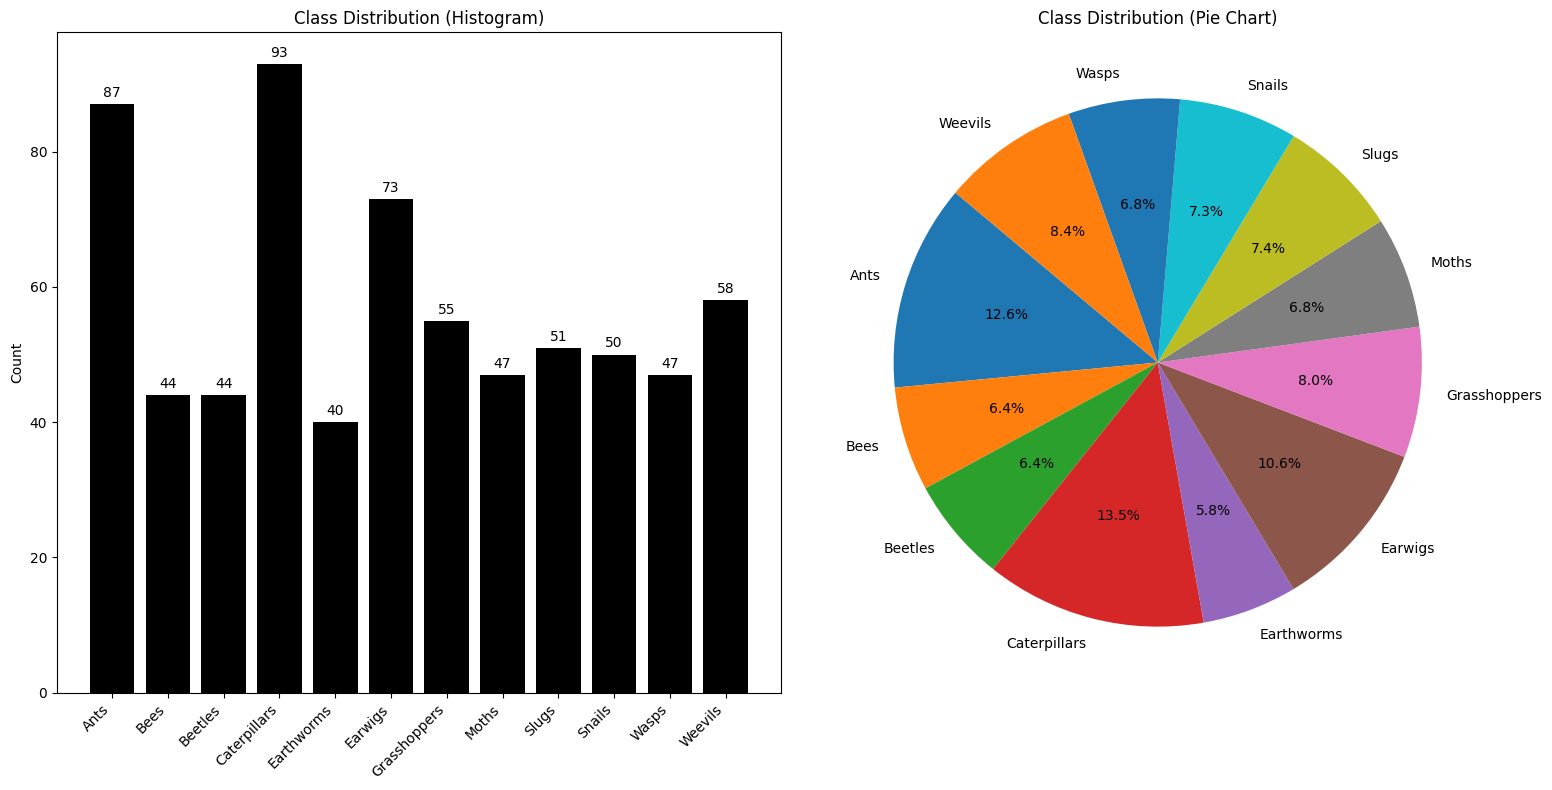

========= Validation Set Distribution =========


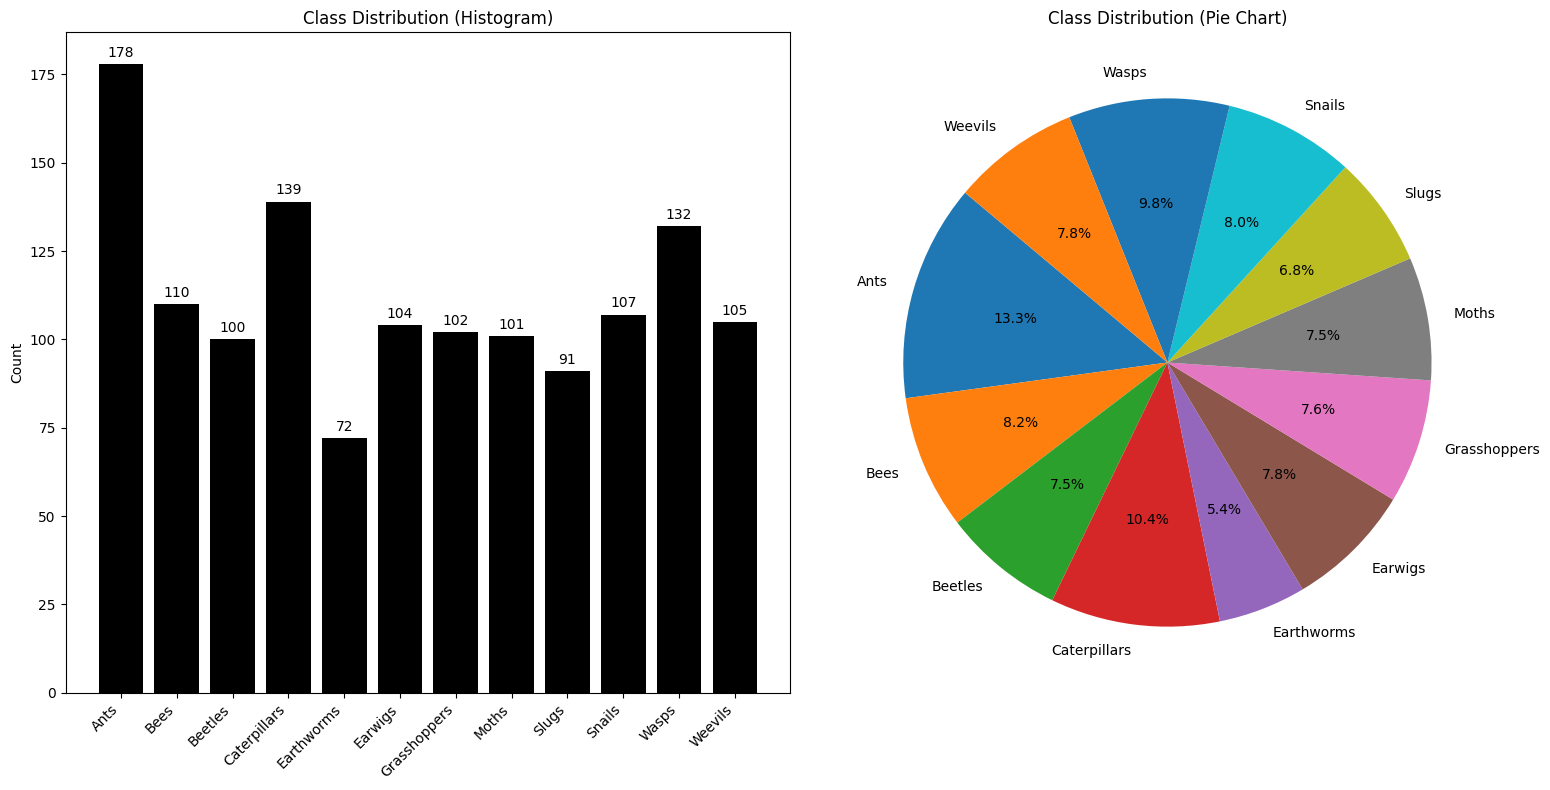

In [5]:
import matplotlib.pyplot as plt

def analyze_distribution(path):
    class_counts = {i: 0 for i in range(len(class_names))}
    for file in path.glob("*.txt"):
        with open(file, 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1
    total = sum(class_counts.values())
    names = [class_names[i] for i in class_counts.keys()]
    rates = [count / total * 100 for count in class_counts.values()]

    fig, axs = plt.subplots(1, 2, figsize=(16, 8))

    bars = axs[0].bar(names, list(class_counts.values()), color='black')
    axs[0].bar_label(bars, padding=3) 
    axs[0].set_xticks(range(len(names)))
    axs[0].set_xticklabels(names, rotation=45, ha='right')
    axs[0].set_ylabel("Count")
    axs[0].set_title("Class Distribution (Histogram)")

    axs[1].pie(rates, labels=names, autopct='%1.1f%%', startangle=140)
    axs[1].set_title("Class Distribution (Pie Chart)")
    
    plt.tight_layout()
    plt.show()

print("========= Training Set Distribution =========")
analyze_distribution(train_lab_path)
print("========= Test Set Distribution =========")
analyze_distribution(test_lab_path)
print("========= Validation Set Distribution =========")
analyze_distribution(valid_lab_path)
    

# 裁剪目标

In [4]:
from tqdm import tqdm

def crop_img(images_path, labels_path, max_no=None):
    cropped_images = {}

    images = list(images_path.glob('*.jpg'))
    if max_no:
        images = images[:max_no]

    for img in tqdm(images, desc="Extracting features"):
        img_path = images_path / img
        lab = labels_path / (img.stem + '.txt')
        img = cv2.imread(str(img))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        if lab.exists():
            with open(lab, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])

                    x1 = max(0, int((cx - bw/2) * w))
                    y1 = max(0, int((cy - bh/2) * h))
                    x2 = min(w, int((cx + bw/2) * w))
                    y2 = min(h, int((cy + bh/2) * h))

                    cropped = img[y1:y2, x1:x2]

                    if cropped.size > 0:
                        if class_id not in cropped_images:
                            cropped_images[class_id] = []
                        cropped_images[class_id].append((str(img_path),cropped))
        else:
            print(f"Label file not found for image: {img.stem}")
    return cropped_images

print("Cropping training images...")
train_cropped = crop_img(train_img_path, train_lab_path)
print("\nCropping testing images...")
test_cropped = crop_img(test_img_path, test_lab_path)
print("\nCropping validation images...")
valid_cropped = crop_img(valid_img_path, valid_lab_path)

Cropping training images...


Extracting features: 100%|██████████| 11502/11502 [01:19<00:00, 144.96it/s]



Cropping testing images...


Extracting features: 100%|██████████| 546/546 [00:05<00:00, 105.16it/s]



Cropping validation images...


Extracting features: 100%|██████████| 1095/1095 [00:10<00:00, 101.87it/s]


# 方法1：传统机器学习的方法

**简介**: HOG(Histogram of Oriented Gradients) 做特征提取， 逻辑回归用于做分类器

**步骤**:
1. 目标检测: 直接用 ground-truth 边界框，即人家标注好的目标框，这样可以只关注分类结果而不必考虑目标检测效果
2. 特征提取: 用 HOG, 捕捉图像中局部的边缘和形状信息，来捕捉纹理和形状特征
3. 分类: 逻辑回归和随机森林进行对比

**备注**: 
传统机器学习方法通常在正确定位目标之后进行分类，因此这儿用真实标注的框的数据作为输入，以保证分类的公平对比和准确性。整个流程相对简单，适合理解与基准测试，特别是在深度学习尚未盛行之前是经典方案。

In [7]:
from skimage.feature import hog
from skimage import color
import numpy as np

# Parameters for HOG
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)
TARGET_SIZE = (128, 128)

def extract_HOG_features(img):
    img = cv2.resize(img, TARGET_SIZE)
    if len(img.shape) == 3:
        img = color.rgb2gray(img)
    else:
        img = img
    features = hog(img, orientations=ORIENTATIONS,
                   pixels_per_cell=PIXELS_PER_CELL,
                   cells_per_block=CELLS_PER_BLOCK,
                   visualize=False, feature_vector=True)
    return features

def apply_HOG(imgset):
    features = []
    labels = []
    for class_id in imgset.keys():
        for _, img in imgset[class_id]:
            features.append(extract_HOG_features(img))
            labels.append(class_id)
    return np.array(features), np.array(labels)
    
print("Extracting HOG features from training set...")
X_train, Y_train = apply_HOG(train_cropped)
print(f"Training samples: {len(X_train)}, Feature dimension: {X_train.shape[1]}")

print("\nExtracting HOG features from test set...")
X_test, Y_test = apply_HOG(test_cropped)
print(f"Test samples: {len(X_test)}, Feature dimension: {X_test.shape[1]}")

print("\nExtracting HOG features from validation set...")
X_val, Y_val = apply_HOG(valid_cropped)
print(f"Validation samples: {len(X_val)}, Feature dimension: {X_val.shape[1]}")


Extracting HOG features from training set...
Training samples: 15282, Feature dimension: 8100

Extracting HOG features from test set...
Test samples: 689, Feature dimension: 8100

Extracting HOG features from validation set...
Validation samples: 1341, Feature dimension: 8100


In [8]:
import time
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score,confusion_matrix
from sklearn.preprocessing import label_binarize
import seaborn as sns

def init_eval_index(dic):
    
    # macro average evaluation
    dic["MAC Precision"] = []
    dic["MAC Recall"] = []
    dic["MAC F1-Score"] = []
    dic["MAC AUC"] = []
        
    # weighted average evaluation
    dic["WTD Precision"] = []
    dic["WTD Recall"] = []
    dic["WTD F1-Score"] = []
    dic["WTD AUC"] = []

    # overall
    dic["Test Accuracy"] = []
    return dic


def eval_classifier(classifier,dic):

    test_start_time = time.time()
    pred = classifier.predict(X_test)
    pred_proba = classifier.predict_proba(X_test)
    test_time = time.time() - test_start_time
    Y_test_bin = label_binarize(Y_test, classes=range(len(class_names)))
    if Y_test_bin.shape[1] == 1:
        Y_test_bin = np.hstack((1 - Y_test_bin, Y_test_bin))

    accuracy = accuracy_score(Y_test, pred)
    dic["Test Accuracy"].append(f"{accuracy:.2%}")

    MAC_pre =  precision_score(Y_test, pred, average='macro', zero_division=0)
    MAC_rec = recall_score(Y_test, pred, average='macro', zero_division=0)
    MAC_f1 = f1_score(Y_test, pred, average='macro', zero_division=0)
    MAC_auc = roc_auc_score(Y_test_bin, pred_proba, average='macro', multi_class='ovr')

    dic["MAC Precision"].append(f"{MAC_pre:.2%}")
    dic["MAC Recall"].append(f"{MAC_rec:.2%}")
    dic["MAC F1-Score"].append(f"{MAC_f1:.2%}")
    dic["MAC AUC"].append(f"{MAC_auc:.2%}")

    WTD_pre =  precision_score(Y_test, pred, average='weighted', zero_division=0)
    WTD_rec = recall_score(Y_test, pred, average='weighted', zero_division=0)
    WTD_f1 = f1_score(Y_test, pred, average='weighted', zero_division=0)
    WTD_auc = roc_auc_score(Y_test_bin, pred_proba, average='weighted', multi_class='ovr')

    dic["WTD Precision"].append(f"{WTD_pre:.2%}")
    dic["WTD Recall"].append(f"{WTD_rec:.2%}")
    dic["WTD F1-Score"].append(f"{WTD_f1:.2%}")
    dic["WTD AUC"].append(f"{WTD_auc:.2%}")

    cm = confusion_matrix(Y_test, pred)
    return pred,pred_proba,cm,dic

def show_results(dic):
    line = "Group          :"
    for i in range(len(list(dic.values())[0])):
        line += f"{i:^8}  "
    print(line)
    for _,para in enumerate(dic.keys()):
        line = f"{para:<15}:  "
        for data in dic[para]:
            line += f"{data:^10}"
        print(line)

def show_cm(cm):
    _, axes = plt.subplots(1, len(cm), figsize = (12*len(cm), 10))
    for i in range(len(cm)):
        sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names, ax=axes[i])
        axes[i].set_xlabel('Pred')
        axes[i].set_ylabel('True')
    plt.tight_layout()
    plt.show()


## 逻辑回归训练
关于参数

**MULTI_CLASS:**: 

(using multinomial as default)
1. `ovr(one-vs-rest):` 对K分类问题训练K个二分类器，每次将某一类别作为正类，其余类别作为负类。适合二分类或多分类问题，简单且计算效率较高。
2. `multinomial:` 直接对多分类问题进行建模，采用softmax函数，数学上更严谨，适合类别间关系复杂的多分类任务。但对计算资源要求更高。

**SOLVER:**
1. `liblinear:` 基于坐标轴下降法（coordinate descent）的优化算法，适合小型数据集和二分类问题，支持L1和L2正则化，但不支持多项式模型。
2. `lbfgs:` 拟牛顿法，适合中小型数据集和多分类问题，支持L2正则化，收敛速度较快，是默认选项。
3. `newton-cg:` 牛顿共轭梯度法，适合多分类问题，支持L2正则化，计算开销较大但精度较高。
4. `sag: ` 随机平均梯度下降法，适用于大规模数据集，收敛速度快，但仅支持L2正则化。
5. `saga:` 是SAG的一个扩展，支持L1、L2和弹性网络正则化，适合大规模数据和稀疏特征，同时支持多分类。

**C:**

表示正则化强度，越大，便允许模型更复杂，容易过拟合，反之容易欠拟合

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)



# parameters for Logistic Regression
LR_dict = {
    "Max Iter": [50, 50, 50],
    # the experiment has shown that it's enough to converge.
    "Solver": ['lbfgs', 'newton-cg', 'sag'],
    "C": [1.0, 1.0, 1.0],
}

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

def LR_train(max_iter, solver, c):
    start_time = time.time()

    classifier = LogisticRegression(
        max_iter = max_iter,            
        solver = solver,            
        C = c,
        random_state = RANDOM_STATE, 
        n_jobs = -1,                  # Use all CPU cores
    )
    classifier.fit(X_train, Y_train)

    train_time = time.time() - start_time

    val_pred = classifier.predict(X_val)
    val_acc = accuracy_score(Y_val, val_pred)
    LR_dict["Val Acc"].append(f"{val_acc:.2%}")
    LR_dict["Train Time"].append(f"{train_time:.2f}s")
    return classifier

LR_dict["Train Time"] = []
LR_dict["Val Acc"] = []

LR_dict = init_eval_index(LR_dict)

LR_pred = []
LR_pred_prob = []
LR_cm = []
for i in range(len(list(LR_dict.values())[0])):
    LR_classifier = LR_train(LR_dict["Max Iter"][i],LR_dict["Solver"][i],LR_dict["C"][i])
    pred,pred_prob,cm,LR_dict = eval_classifier(LR_classifier,LR_dict)
    LR_pred.append(pred)
    LR_pred_prob.append(pred_prob)
    LR_cm.append(cm)
    

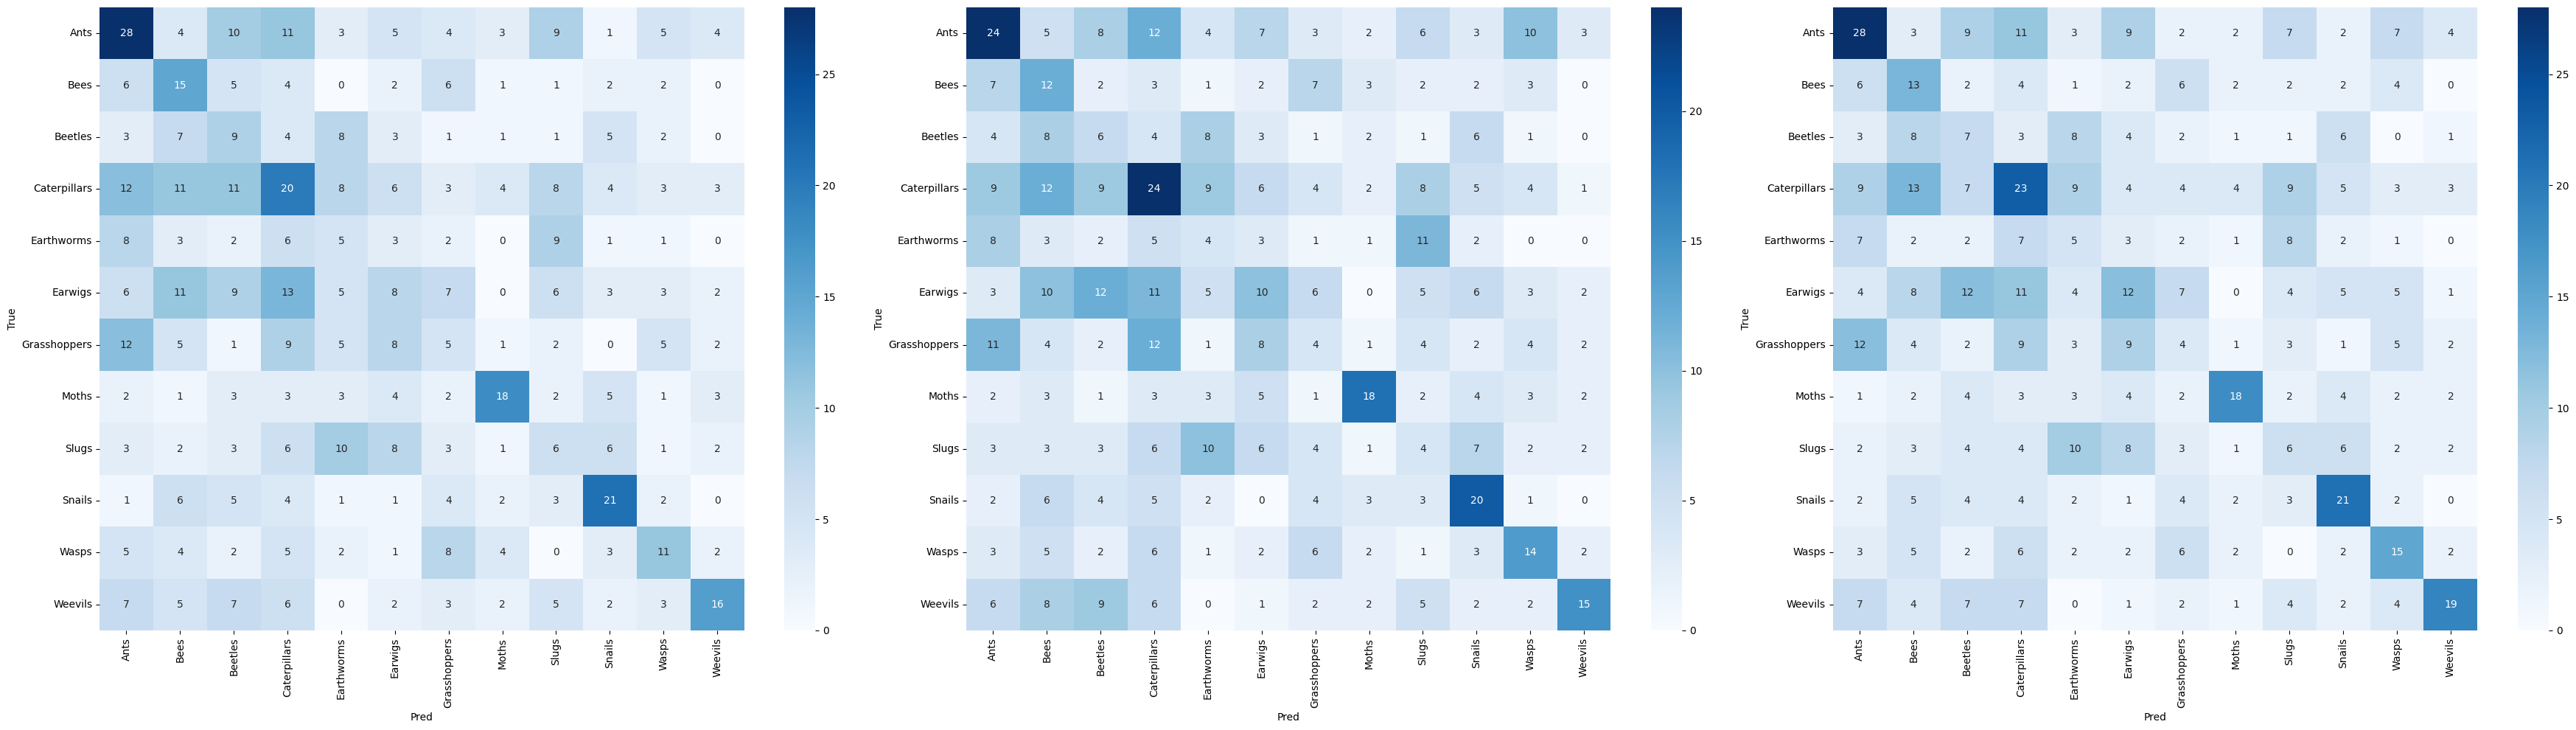

Group          :   0         1         2      
Max Iter       :      50        50        50    
Solver         :    lbfgs   newton-cg    sag    
C              :     1.0       1.0       1.0    
Train Time     :    22.57s   124.29s   149.67s  
Val Acc        :    23.34%    24.46%    24.91%  
MAC Precision  :    24.75%    23.82%    25.86%  
MAC Recall     :    23.65%    22.26%    24.61%  
MAC F1-Score   :    23.66%    22.37%    24.76%  
MAC AUC        :    70.47%    70.89%    71.56%  
WTD Precision  :    24.93%    24.48%    26.48%  
WTD Recall     :    23.51%    22.50%    24.82%  
WTD F1-Score   :    23.73%    22.87%    25.23%  
WTD AUC        :    69.98%    70.37%    71.12%  
Test Accuracy  :    23.51%    22.50%    24.82%  


In [10]:
show_cm(LR_cm)
show_results(LR_dict)

验证集准确率只有23.79%（12类昆虫中随机猜测准确率大概8%），说明模型表现较差。常见可能原因及改进方向包括：

**可能原因:**
1. `特征表达不足:` HOG主要捕捉边缘和方向梯度信息，可能对复杂纹理和颜色信息捕捉有限，不够区分不同昆虫。

2. `模型能力有限:` 逻辑回归是线性分类器，对于复杂的非线性分类任务表现有限，12类多分类问题较难仅用线性决策边界区分。

3. `数据预处理或划分问题:` 归一化不当、数据集过小、类别严重不平衡等都可能影响效果。

4. `参数调优不足:` 正则化参数C、迭代次数等未调好，或者HOG提取参数如单元格大小、区块大小不合适。

**改进建议:**
1. `丰富特征:` 结合颜色直方图、纹理特征（如LBP），或使用深度学习自动特征提取（卷积神经网络）往往效果更好。

2. `更强模型:` 尝试随机森林、支持向量机，或深度学习模型如CNN等非线性模型。

3. `增加数据量和数据增强:` 扩充样本，使用旋转、镜像、变换等数据增强提升泛化能力。

4. `细调HOG参数:` 优化单元格大小、块大小、梯度方向数等，找到更适合昆虫图像的特征尺度。

5. `调参和交叉验证:` 细致调节模型参数和特征提取参数，采用交叉验证选最优组合。

6. `考虑滤除噪声及图像预处理:` 提高图像质量，有助提升特征的判别力。

综上，HOG+逻辑回归可作为起点，但较佳方案需结合更丰富特征和更复杂模型，或转深度学习路线.​

## 随机森林

## 随机森林训练
关于参数

**N_ESTIMATORS:**: 

指定森林中决策树的数量。更多树通常能提高模型的性能和稳定性，但会增加训练和预测的计算成本。比如200棵树可以保证模型有较强的拟合能力和抗过拟合能力，但过多也会带来计算开销较大

**MAX_DEPTH:**

限制每棵决策树的最大深度，防止过拟合。深度越大，树越复杂，对训练数据拟合越细致，但也可能导致过拟合。设置30深度一般是一个适中值，可以适应多数任务

**MIN_SAMPLE_SPLIT:**

（内部节点再划分所需最小样本数）：控制一个节点继续拆分所需的最少样本数量。数值越大，约束越强，树越浅，防止过拟合。5表示节点至少有5个样本才继续分裂，否则停止划分

In [11]:
from sklearn.ensemble import RandomForestClassifier

# parameters for Random Forest
RF_dict = {
    "N Estimators": [200, 200, 200, 200, 200, 200],
    "Max Depth": [20, 25, 30, 20, 25, 30],
    "Min Samples Split": [5, 5, 5, 10, 10, 10]
}

def RF_train(N_estimators, max_depth, min_samples_split):
    start_time = time.time()
    classifier = RandomForestClassifier(
        n_estimators = N_estimators, 
        max_depth = max_depth,
        min_samples_split = min_samples_split, 
        random_state = 10086,
        n_jobs = -1
    )
    classifier.fit(X_train, Y_train)

    train_time = time.time() - start_time
    val_pred = classifier.predict(X_val)
    val_acc = accuracy_score(Y_val, val_pred)
    RF_dict["Train Time"].append(f"{train_time:.2f}s")
    RF_dict["Val Acc"].append(f"{val_acc:.2%}")
    
    return classifier

RF_dict["Train Time"] = []
RF_dict["Val Acc"] = []

RF_dict = init_eval_index(RF_dict)

RF_pred = []
RF_pred_prob = []
RF_cm = []

for i in range(len(list(RF_dict.values())[0])):
    RF_classifier = RF_train(RF_dict["N Estimators"][i],RF_dict["Max Depth"][i],RF_dict["Min Samples Split"][i])
    pred,pred_prob,cm,RF_dict = eval_classifier(RF_classifier,RF_dict)
    RF_pred.append(pred)
    RF_pred_prob.append(pred_prob)
    RF_cm.append(cm)
    


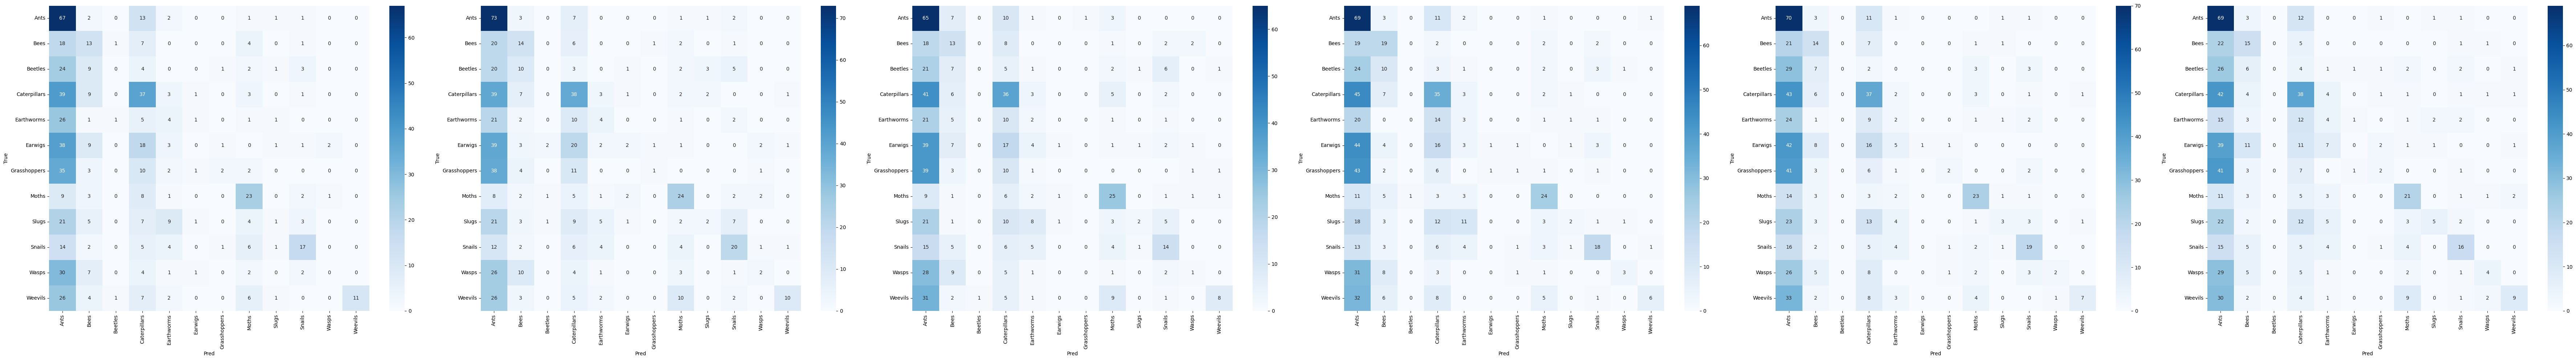

Group          :   0         1         2         3         4         5      
N Estimators   :     200       200       200       200       200       200    
Max Depth      :      20        25        30        20        25        30    
Min Samples Split:      5         5         5         10        10        10    
Train Time     :    37.81s    36.43s    41.56s    38.42s    38.61s    39.74s  
Val Acc        :    25.28%    25.65%    25.21%    26.62%    25.58%    24.76%  
MAC Precision  :    27.74%    31.24%    26.71%    36.83%    42.88%    31.71%  
MAC Recall     :    21.99%    23.97%    20.86%    23.21%    22.60%    23.20%  
MAC F1-Score   :    19.09%    20.89%    17.52%    20.43%    20.32%    21.26%  
MAC AUC        :    72.72%    72.72%    72.61%    73.52%    73.24%    72.86%  
WTD Precision  :    27.98%    31.62%    27.49%    36.80%    43.88%    30.82%  
WTD Recall     :    25.40%    27.58%    24.24%    26.27%    26.12%    26.56%  
WTD F1-Score   :    20.25%    22.07%    18.74%    21

In [12]:
show_cm(RF_cm)
show_results(RF_dict)

# 方法2: 神经网络 (传统CNN)



## 老古董(CNN)
只用来做图像分类的，不搞目标检测

### 数据处理

In [5]:
# create folders to load dataset for NN
NN_dataset_path = Path("./NN_Dataset")
NN_dataset_path.mkdir(exist_ok=True)


transform = transforms.Compose([
    # 统一将数据先搞成640*640的（其实有点太大了）
    transforms.Resize((224, 224)),
    # 将PIL转成pytorch的tensor
    transforms.ToTensor(),
    # 按照ImageNet上面统计过的均值和标准差进行归一化（提升训练效果）
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def create_NN_Folder(img_cropped,type):
    folder_path = NN_dataset_path / type
    folder_path.mkdir(exist_ok=True)
    for class_id in img_cropped.keys():
        class_path = folder_path / class_names[class_id]
        class_path.mkdir(exist_ok=True)
        for i, (_,img) in enumerate(img_cropped[class_id]):
            img_path = class_path / f"{class_names[class_id]}_{i}.jpg"
            cv2.imwrite(img_path,img)
    return datasets.ImageFolder(folder_path,transform=transform)
    
print("Creating Folders for NN_Train.......")
NN_train_folder = create_NN_Folder(train_cropped,"train")
print("Creating Folders for NN_Test.......")
NN_test_folder = create_NN_Folder(test_cropped,"test")
print("Creating Folders for NN_Valid.......")
NN_valid_folder = create_NN_Folder(valid_cropped,"valid")
print("All Folders are successfully created!")

Creating Folders for NN_Train.......
Creating Folders for NN_Test.......
Creating Folders for NN_Valid.......
All Folders are successfully created!


In [6]:
from NN_Models import DenseNet,GoogleNet,ResNet,VGG,RetinaNet
import time

BATCH_SIZE = 64
LR = 1e-4
NUM_EPOCHS = 10

NN_train_loader = DataLoader(NN_train_folder,batch_size=BATCH_SIZE,shuffle=True,num_workers=8)
NN_valid_loader = DataLoader(NN_valid_folder,batch_size=BATCH_SIZE,shuffle=False,num_workers=8)
NN_test_loader = DataLoader(NN_test_folder,batch_size=BATCH_SIZE,shuffle=False,num_workers=8)
loss_func = nn.CrossEntropyLoss()

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, top_k_accuracy_score
import numpy as np
import torch.nn.functional as F

def train(model_name):
    match model_name:
        case "DenseNet":
            model = DenseNet.Build(len(class_names))
        case "GoogleNet":
            model = GoogleNet.Build(len(class_names))
        case "ResNet":
            model = ResNet.Build(len(class_names))
        case "VGG":
            model = VGG.Build(len(class_names))
        case "RetinaNet":
            model = RetinaNet.Build(len(class_names))

    model = model.to("cuda:0")
    model = torch.nn.DataParallel(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    res = {}
    total_time = 0
    for epoch in range(NUM_EPOCHS):
        start = time.time()
        model.train()

        running_loss = 0.0
        for images, labels in NN_train_loader:
            images, labels = images.to("cuda"), labels.to("cuda")
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_func(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(NN_train_loader)

        model.eval()
        running_val_loss = 0.0
        all_preds = []
        all_labels = []
        all_probs = []

        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for images, labels in NN_valid_loader:
                images, labels = images.to("cuda"), labels.to("cuda")
                outputs = model(images)
                loss = loss_func(outputs, labels)
                running_val_loss += loss.item()

                probs = F.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

            for images, labels in NN_test_loader:
                images, labels = images.to("cuda"), labels.to("cuda")
                outputs = model(images)
                _, predicted = torch.max(outputs, 1) 
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        

        val_loss = running_val_loss / len(NN_valid_loader)
        val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
        top5_acc = top_k_accuracy_score(all_labels, np.array(all_probs), k=5, labels=list(range(len(class_names))))

        test_acc = test_correct / test_total

        conf_mat = confusion_matrix(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)


        epoch_time = time.time() - start
        total_time += epoch_time
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}: "
              f"Train Loss={train_loss:.2f}, Val Loss={val_loss:.2f}, "
              f"Val Acc={val_acc:.2%}, Top-5 Acc={top5_acc:.2%}, "
              f"Precision={precision:.2%}, Recall={recall:.2%}, F1={f1:.2f}, "
              f"Time={epoch_time:.2f}s, Test Acc={test_acc:.2%}")




    res["Avg time"] = total_time / NUM_EPOCHS
    res["Val acc"] = val_acc
    res["Train loss"] = train_loss
    res["Val loss"] = val_loss
    res["Top5 acc"] = top5_acc
    res["Precision"] = precision
    res["Recall"] = recall
    res["F1"] = f1
    res["Conf Mat"] = conf_mat

    torch.save(model.state_dict(), f"{model_name}.pth")
    return res


In [ ]:
# print("Starting to train VGG.....")
# VGG_res = train("VGG")

# VGG is too old and it costs too much time.........

In [7]:
print("Starting to train GoogleNet.....")
GoogleNet_res = train("GoogleNet")

Starting to train GoogleNet.....
Epoch 1/10: Train Loss=2.44, Val Loss=2.43, Val Acc=13.35%, Top-5 Acc=50.26%, Precision=3.89%, Recall=8.40%, F1=0.02, Time=86.22s, Test Acc=12.63%
Epoch 2/10: Train Loss=2.33, Val Loss=2.30, Val Acc=18.87%, Top-5 Acc=61.52%, Precision=7.30%, Recall=13.79%, F1=0.06, Time=81.97s, Test Acc=16.11%
Epoch 3/10: Train Loss=2.23, Val Loss=2.15, Val Acc=25.21%, Top-5 Acc=69.87%, Precision=20.98%, Recall=23.89%, F1=0.19, Time=86.23s, Test Acc=22.79%
Epoch 4/10: Train Loss=2.05, Val Loss=2.08, Val Acc=29.53%, Top-5 Acc=72.71%, Precision=26.31%, Recall=28.39%, F1=0.24, Time=84.26s, Test Acc=28.45%
Epoch 5/10: Train Loss=1.95, Val Loss=1.97, Val Acc=31.69%, Top-5 Acc=75.09%, Precision=24.85%, Recall=29.15%, F1=0.25, Time=82.34s, Test Acc=31.79%
Epoch 6/10: Train Loss=1.87, Val Loss=1.96, Val Acc=34.00%, Top-5 Acc=75.17%, Precision=25.51%, Recall=31.47%, F1=0.26, Time=81.57s, Test Acc=32.37%
Epoch 7/10: Train Loss=1.82, Val Loss=1.91, Val Acc=35.57%, Top-5 Acc=78.37%

In [ ]:
print("Starting to train ResNet.....")
ResNet_res = train("ResNet")

Starting to train ResNet.....
Epoch 1/10: Train Loss=1.81, Val Loss=1.75, Val Acc=43.18%, Top-5 Acc=83.97%, Precision=46.85%, Recall=40.31%, F1=0.39, Time=76.02s, Test Acc=41.80%
Epoch 2/10: Train Loss=1.33, Val Loss=1.57, Val Acc=47.50%, Top-5 Acc=90.08%, Precision=54.24%, Recall=46.47%, F1=0.46, Time=75.38s, Test Acc=47.02%
Epoch 3/10: Train Loss=1.04, Val Loss=1.62, Val Acc=49.37%, Top-5 Acc=89.41%, Precision=57.11%, Recall=48.05%, F1=0.47, Time=75.99s, Test Acc=53.27%
Epoch 4/10: Train Loss=0.80, Val Loss=1.28, Val Acc=60.03%, Top-5 Acc=92.32%, Precision=62.19%, Recall=58.24%, F1=0.57, Time=78.52s, Test Acc=57.04%
Epoch 5/10: Train Loss=0.57, Val Loss=1.25, Val Acc=60.48%, Top-5 Acc=94.03%, Precision=61.87%, Recall=60.17%, F1=0.60, Time=76.20s, Test Acc=60.23%
Epoch 6/10: Train Loss=0.38, Val Loss=1.36, Val Acc=61.00%, Top-5 Acc=93.36%, Precision=64.57%, Recall=60.94%, F1=0.61, Time=75.97s, Test Acc=57.76%
Epoch 7/10: Train Loss=0.24, Val Loss=1.66, Val Acc=56.00%, Top-5 Acc=92.69%

In [11]:
print("Starting to train DenseNet.....")
DenseNet_res = train("DenseNet")

Starting to train DenseNet.....
Epoch 1/10: Train Loss=2.04, Val Loss=1.90, Val Acc=38.18%, Top-5 Acc=81.13%, Precision=36.88%, Recall=35.03%, F1=0.33, Time=75.30s
Epoch 2/10: Train Loss=1.70, Val Loss=1.66, Val Acc=47.05%, Top-5 Acc=85.91%, Precision=46.10%, Recall=44.03%, F1=0.43, Time=70.95s
Epoch 3/10: Train Loss=1.48, Val Loss=1.62, Val Acc=46.76%, Top-5 Acc=87.84%, Precision=49.62%, Recall=42.91%, F1=0.42, Time=70.31s
Epoch 4/10: Train Loss=1.30, Val Loss=1.43, Val Acc=53.99%, Top-5 Acc=90.75%, Precision=54.97%, Recall=52.71%, F1=0.52, Time=69.89s
Epoch 5/10: Train Loss=1.17, Val Loss=1.36, Val Acc=56.08%, Top-5 Acc=91.13%, Precision=56.61%, Recall=54.59%, F1=0.54, Time=67.63s
Epoch 6/10: Train Loss=1.06, Val Loss=1.42, Val Acc=53.99%, Top-5 Acc=89.71%, Precision=58.21%, Recall=53.46%, F1=0.54, Time=67.13s
Epoch 7/10: Train Loss=0.96, Val Loss=1.17, Val Acc=62.42%, Top-5 Acc=93.89%, Precision=62.15%, Recall=61.26%, F1=0.61, Time=66.94s
Epoch 8/10: Train Loss=0.86, Val Loss=1.19, 

## 目标检测+图像分类

In [ ]:
from tqdm import tqdm
BATCH_SIZE = 64
IMG_RESIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_RESIZE, IMG_RESIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  std=[0.229, 0.224, 0.225]),
])

from PIL import Image

def preprocess(images_path, labels_path):
    data_list = []
    images_list = list(images_path.glob('*.jpg'))
    for img_path in tqdm(images_list, desc="Extracting Images"):
        label_file = labels_path / (img_path.stem + '.txt')
        img = Image.open(img_path).convert("RGB") 
        w, h = img.size 
        
        boxes = []
        labels = []
        if label_file.exists():
            with open(label_file, "r") as f:
                for line in f:
                    content = line.strip().split()
                    labels.append(int(content[0]))
                    cx, cy, bw, bh = map(float, content[1:5])
                    x1 = max(0, int((cx - bw / 2) * w))
                    y1 = max(0, int((cy - bh / 2) * h))
                    x2 = min(w, int((cx + bw / 2) * w))
                    y2 = min(h, int((cy + bh / 2) * h))
                    boxes.append([x1, y1, x2, y2])
        
        # Because we have resized the image, we have to resize the label
        scale_x = IMG_RESIZE / w
        scale_y = IMG_RESIZE / h
        boxes = [[x1 * scale_x, y1 * scale_y, x2 * scale_x, y2 * scale_y] for (x1, y1, x2, y2) in boxes]

        img_t = transform(img)

        boxes_tensor = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels_tensor = torch.tensor(labels, dtype=torch.long) if labels else torch.zeros((0,), dtype=torch.long)

        data_list.append((img_t, boxes_tensor, labels_tensor))

    return data_list



train_data = preprocess(train_img_path, train_lab_path)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda x: x)
valid_data = preprocess(valid_img_path, valid_lab_path)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda x: x)


Extracting Images: 100%|██████████| 1095/1095 [00:05<00:00, 217.26it/s]


In [ ]:
def loss_function(cls_logits, bbox_preds, labels, bbox_targets):
    cls_loss = nn.CrossEntropyLoss()(cls_logits, labels)
    pos_inds = labels > 0
    if pos_inds.sum() > 0:
        bbox_preds = bbox_preds[pos_inds]
        labels_pos = labels[pos_inds]
        bbox_preds = bbox_preds.view(-1, cls_logits.size(1), 4)
        bbox_preds = bbox_preds[range(bbox_preds.size(0)), labels_pos]
        bbox_loss = nn.SmoothL1Loss()(bbox_preds, bbox_targets[pos_inds])
    else:
        bbox_loss = torch.tensor(0.).to(cls_logits.device)
    return cls_loss + bbox_loss

In [ ]:
from NN_Models import FasterR

def validate(model, valid_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in valid_loader:
            imgs, all_rois, all_labels_batch = [], [], []
            batch_index = 0
            for img_t, boxes_t, labels_t in batch:
                imgs.append(img_t)
                rois = torch.cat((
                    torch.full((boxes_t.shape[0],1), batch_index, dtype=torch.float32), 
                    boxes_t), dim=1)
                all_rois.append(rois)
                all_labels_batch.append(labels_t)
                batch_index += 1
                
            imgs = torch.stack(imgs).to("cuda")
            all_rois = torch.cat(all_rois).to("cuda")
            all_labels_batch = torch.cat(all_labels_batch).to("cuda")
            
            cls_logits, _ = model(imgs, all_rois)
            preds = cls_logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(all_labels_batch.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = np.mean(all_preds == all_labels)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    conf_mat = confusion_matrix(all_labels, all_preds)
    
    return accuracy, precision, recall, f1, conf_mat


def train(model_name, train_loader, valid_loader, num_epochs=10):
    match model_name:
        case "Faster_R_CNN":
            model = FasterR.Build(len(class_names))

    model = model.to("cuda:0")
    model = torch.nn.DataParallel(model)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        count = 0
        for batch in train_loader:
            count += 1
            imgs, all_rois, all_labels = [], [], []
            batch_index = 0
            for img_t, boxes_t, labels_t in batch:
                imgs.append(img_t)
                rois = torch.cat((
                    torch.full((boxes_t.shape[0],1), batch_index, dtype=torch.float32), 
                    boxes_t), dim=1)
                all_rois.append(rois)
                all_labels.append(labels_t)
                batch_index += 1
            imgs = torch.stack(imgs).to("cuda")
            all_rois = torch.cat(all_rois).to("cuda")
            all_labels = torch.cat(all_labels).to("cuda")
            bbox_targets = all_rois[:,1:] 

            optimizer.zero_grad()
            cls_logits, bbox_preds = model(imgs, all_rois)
            loss = loss_function(cls_logits, bbox_preds, all_labels, bbox_targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        val_acc, val_precision, val_recall, val_f1, val_conf_mat = validate(model, valid_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(train_loader):.4f}, "
              f"Valid Acc: {val_acc:.2%}, Precision: {val_precision:.2%}, "
              f"Recall: {val_recall:.2%}, F1: {val_f1:.2%}")
        print(f"Confusion Matrix:\n{val_conf_mat}\n")


In [ ]:
import gc
gc.collect()               # Python回收垃圾
torch.cuda.empty_cache()   # 释放GPU显存缓存

NUM_EPOCHS = 10
train("Faster_R_CNN",train_loader,valid_loader,NUM_EPOCHS)

Epoch 1/10, Loss: 70.7315, Valid Accuracy: 0.5302
Epoch 2/10, Loss: 22.1137, Valid Accuracy: 0.7487
Epoch 3/10, Loss: 12.6755, Valid Accuracy: 0.7987
Epoch 4/10, Loss: 7.7817, Valid Accuracy: 0.7688
Epoch 5/10, Loss: 6.6152, Valid Accuracy: 0.7770
Epoch 6/10, Loss: 6.0025, Valid Accuracy: 0.8106
Epoch 7/10, Loss: 5.7425, Valid Accuracy: 0.8404
Epoch 8/10, Loss: 4.7566, Valid Accuracy: 0.8098
Epoch 9/10, Loss: 4.0903, Valid Accuracy: 0.8434
Epoch 10/10, Loss: 3.6309, Valid Accuracy: 0.8523
